<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/35_Poly_logictic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression,Ridge,SGDRegressor,Lasso,ElasticNet,LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error,accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve
from sklearn.preprocessing import StandardScaler,PolynomialFeatures,LabelEncoder
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.datasets import make_regression, load_diabetes
import  plotly.express as px
import plotly.graph_objects as go
from sklearn.datasets import load_diabetes,make_classification,load_iris
import time
import matplotlib.animation as animation
from sklearn.svm import SVC

import random
from mlxtend.plotting import  plot_decision_regions


In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/MachineLearning/main/ushape.csv")

In [ ]:
df.head()

,X,Y,class
0,0.0316,0.9870,0.0
1,2.1200,-0.0462,1.0
2,0.8820,-0.0758,0.0
3,-0.0551,-0.0373,1.0
4,0.8300,-0.5390,1.0


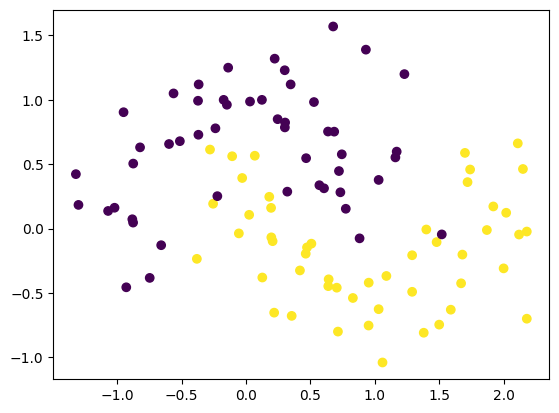

In [ ]:
plt.scatter(df["X"],df["Y"],c=df["class"])

In [ ]:
df.head(1)

,X,Y,class
0,0.0316,0.987,0.0


In [ ]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [54]:
poly=PolynomialFeatures(degree=3)
X_train_tf=poly.fit_transform(X_train)

In [55]:
lr=LogisticRegression(max_iter=5000)
lr.fit(X_train_tf,y_train)


LogisticRegression(max_iter=5000)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


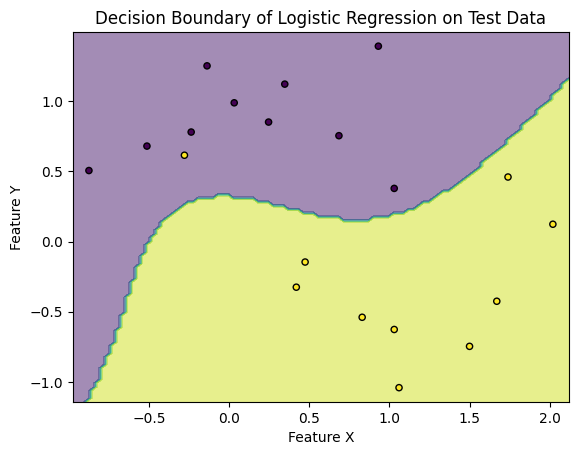

In [62]:
# Determine the range for the grid based on X_test
x_min, x_max = X_test.iloc[:, 0].min() - 0.1, X_test.iloc[:, 0].max() + 0.1
y_min, y_max = X_test.iloc[:, 1].min() - 0.1, X_test.iloc[:, 1].max() + 0.1

# Create a meshgrid
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Flatten the meshgrid points for prediction
grid_points = poly.transform(np.c_[xx.ravel(), yy.ravel()])

# Predict classes for all points in the meshgrid
Z = lr.predict(grid_points)

# Reshape the predictions back to the meshgrid shape
Z = Z.reshape(xx.shape)

# Plot the contourf and scatter original points
plt.contourf(xx, yy, Z, alpha=0.5)
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test, s=20, edgecolor='k')
plt.title('Decision Boundary of Logistic Regression on Test Data')
plt.xlabel('Feature X')
plt.ylabel('Feature Y')
plt.show()